In [14]:
import sys
print(sys.path)

['/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/v2', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python312.zip', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/lib-dynload', '', '/home/amunif/.local/lib/python3.12/site-packages', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages']


In [1]:
import os
import random

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import my_util
import BinaryClassifier as BC

In [2]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 200
START_EPOCH = 0

NUM_ITEMS = 1_000_000
BATCH_SIZE = 128

# NUM_ITEMS = 100_000
# BATCH_SIZE = 64

DROPOUT_RATE = 0.3

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-leakyrelu-lrscheduler-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'model', MODE, "v2", f'{PREFIX}-checkpoint-{SUFFIX}.pt')

IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'train', MODE, "v2", f"{PREFIX}-ranking-{SUFFIX}.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'test', MODE, "v2", f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'train', MODE, "v2", f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'test', MODE, "v2", f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'roc', MODE, "v2", f"{PREFIX}-roc-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'confusion_matrix', MODE, "v2", f"{PREFIX}-cm-{SUFFIX}.png")

INPUT_SIZE = 40_000

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/all_features/v2/dol1l2-leakyrelu-lrscheduler-0.3-checkpoint-1000000-200-128-0.005-0.001.pt


In [3]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [4]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [5]:
# Initialize the model
# model = BC.EnhancedBinaryClassifier(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)
model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

In [6]:
# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

In [7]:
# Optimizer
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

In [8]:
# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [9]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/all_features/v2/dol1l2-leakyrelu-lrscheduler-0.3-checkpoint-1000000-200-128-0.005-0.001.pt exists. Resuming training from epoch 200.


In [10]:
START_EPOCH

200

In [11]:
print(train_losses)
print(val_losses)

[0.621, 0.5982, 0.5923, 0.588, 0.5858, 0.5839, 0.5821, 0.5812, 0.5791, 0.5778, 0.5757, 0.5746, 0.5737, 0.5725, 0.5707, 0.5714, 0.5698, 0.5668, 0.5678, 0.5654, 0.5639, 0.5636, 0.5631, 0.5601, 0.5605, 0.5592, 0.5591, 0.5567, 0.5556, 0.555, 0.5541, 0.5542, 0.554, 0.5541, 0.5541, 0.5537, 0.5544, 0.5547, 0.5542, 0.554, 0.5536, 0.5537, 0.5534, 0.5541, 0.5542, 0.5531, 0.5537, 0.5529, 0.5538, 0.5539, 0.553, 0.5532, 0.554, 0.5536, 0.555, 0.554, 0.5531, 0.5536, 0.5542, 0.5538, 0.5536, 0.5537, 0.5542, 0.5545, 0.5539, 0.555, 0.5534, 0.554, 0.5536, 0.5551, 0.5528, 0.5546, 0.5541, 0.5528, 0.5539, 0.5534, 0.5529, 0.554, 0.554, 0.553, 0.554, 0.5541, 0.5542, 0.5542, 0.5541, 0.5541, 0.5532, 0.5539, 0.5544, 0.5538, 0.5536, 0.5535, 0.5543, 0.5542, 0.554, 0.5545, 0.5551, 0.5533, 0.5539, 0.554, 0.5539, 0.554, 0.553, 0.5545, 0.5541, 0.5542, 0.5544, 0.5537, 0.5531, 0.5543, 0.5543, 0.5537, 0.5533, 0.5543, 0.5537, 0.5528, 0.5531, 0.5535, 0.5538, 0.5536, 0.5528, 0.5537, 0.5533, 0.553, 0.5534, 0.5539, 0.5532, 0.5

In [12]:
print(train_accuracies)
print(val_accuracies)

[70.09, 70.43, 70.52, 70.64, 70.68, 70.84, 70.95, 71.03, 71.09, 71.25, 71.4, 71.38, 71.44, 71.49, 71.64, 71.53, 71.65, 71.91, 71.83, 71.9, 71.98, 72.04, 72.06, 72.31, 72.28, 72.3, 72.37, 72.53, 72.69, 72.68, 72.76, 72.78, 72.79, 72.77, 72.75, 72.84, 72.76, 72.71, 72.76, 72.79, 72.8, 72.81, 72.79, 72.76, 72.74, 72.84, 72.77, 72.85, 72.86, 72.84, 72.83, 72.81, 72.78, 72.86, 72.71, 72.74, 72.86, 72.79, 72.77, 72.78, 72.8, 72.81, 72.81, 72.76, 72.77, 72.63, 72.8, 72.76, 72.84, 72.68, 72.87, 72.67, 72.79, 72.87, 72.79, 72.83, 72.88, 72.69, 72.75, 72.85, 72.79, 72.76, 72.77, 72.75, 72.81, 72.78, 72.84, 72.75, 72.76, 72.76, 72.78, 72.8, 72.76, 72.79, 72.74, 72.66, 72.72, 72.86, 72.7, 72.75, 72.78, 72.74, 72.84, 72.71, 72.79, 72.78, 72.74, 72.8, 72.83, 72.75, 72.78, 72.81, 72.83, 72.65, 72.76, 72.83, 72.86, 72.79, 72.81, 72.75, 72.85, 72.76, 72.83, 72.84, 72.83, 72.82, 72.86, 72.76, 72.84, 72.77, 72.74, 72.77, 72.78, 72.76, 72.83, 72.79, 72.83, 72.79, 72.75, 72.81, 72.83, 72.84, 72.83, 72.75, 

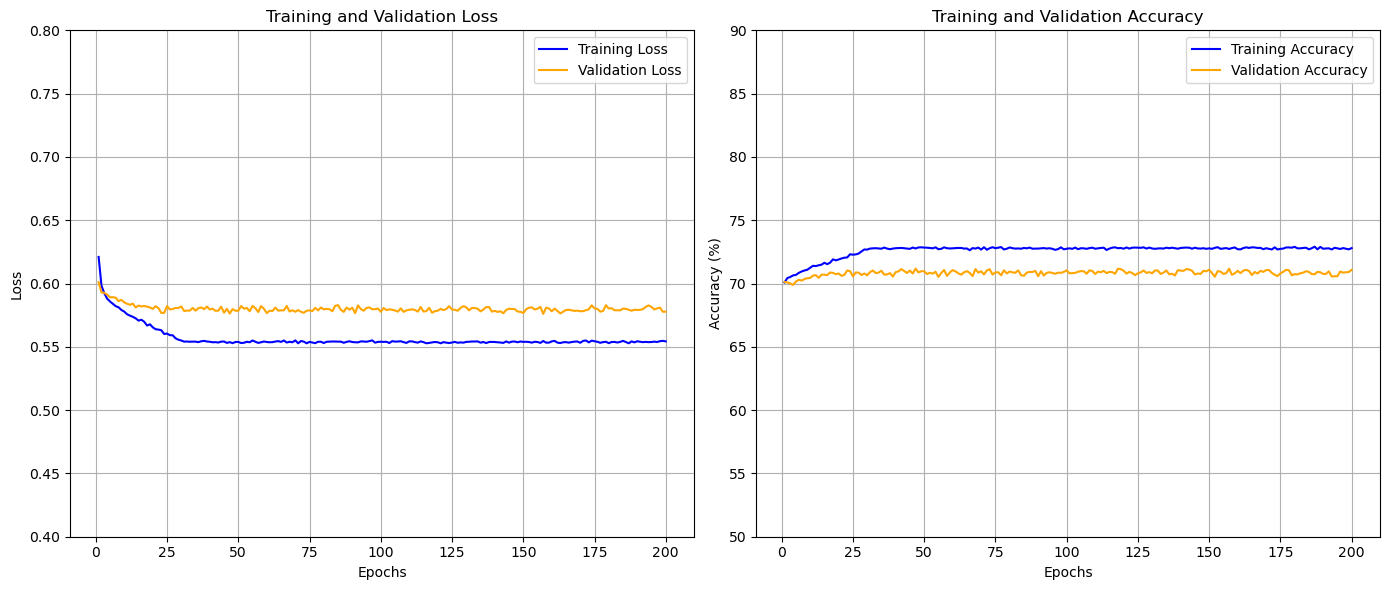

In [13]:
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)